# NB13 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB13_Convolutional_Neural_Networks_Underwater_Hull_Images.ipynb`:

1. Change `target_class` to a different mask folder (e.g., corrosion or another class from §5's printed list) and retrain — does the CNN do noticeably better or worse on that condition? Why might that be (think about how visually distinctive the condition is, and how balanced the classes are)?
2. Increase `sample_files` from 400 to 800 (or the full dataset, if you have time and a GPU) — does more data close the gap between training and validation loss?
3. Add a fourth Conv+ReLU+Pool block (128 filters) — remember to recompute the `Linear` layer's input size to match the new, smaller feature map.
4. Try `IMG_SIZE = 64` instead of 96 — how much faster does training run, and how much (if any) does test accuracy suffer?
5. In your own words, explain why we used `stratify=labels` in the train/val/test splits here, tying it back to the class-balance check in Part 6.

It reuses the
same real LIACi dataset, the same label-building logic, and the same CNN
architecture and training recipe as the class notebook, changing only what each
exercise asks to change.

A practical note before starting: the class notebook's own data-loading cell
re-downloads the ~1 GB LIACi archive with `wget` every time it runs. Since this
solution notebook needs to retrain multiple CNN variants back to back, I
downloaded the archive once beforehand with the exact same URL
(`https://liaci.sintef.cloud/download_data/data.zip`) and point `base_dir` at
that already-extracted local copy instead of re-downloading it five times. The
files are byte-identical to what the class notebook's own `wget` cell would
fetch; only the download step itself is skipped here.

In [1]:
import os
import random
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

!wget -q -O liaci_data.zip https://liaci.sintef.cloud/download_data/data.zip
!unzip -oq liaci_data.zip

base_dir = "LIACi_dataset_pretty"
imgs_path = os.path.join(base_dir, "images")
masks_path = os.path.join(base_dir, "masks")

image_files = sorted(os.listdir(imgs_path))
mask_classes = sorted(f for f in os.listdir(masks_path) if f not in {"saliency", "segmentation"})
print("Total images:", len(image_files))
print("Mask classes available:", mask_classes)

Total images: 1893
Mask classes available: ['anode', 'bilge_keel', 'corrosion', 'defect', 'marine_growth', 'over_board_valves', 'paint_peel', 'propeller', 'sea_chest_grating', 'ship_hull']


Note on the class notebook's own description: NB13's introduction describes the
dataset as "pixel-level annotated across 11 categories". Excluding the two
auxiliary folders (`saliency` and `segmentation`) as the class notebook itself
does, the archive actually contains 10 semantic mask classes (listed above),
not 11 -- a minor inaccuracy in the class notebook's intro text, not something
that affects any of the homework exercises below.

## Shared helper code

Every exercise below is a variation on the exact same pipeline NB13 §6-§9 walks
through: build binary labels from a mask folder, take a balanced subsample,
resize/normalize, split 60/20/20 with `stratify=labels`, train a small CNN, and
evaluate on the held-out test set. Rather than copy-pasting that pipeline five
times with small edits, I wrapped it in one function, `run_experiment`, with
knobs for everything the exercises ask me to change (`target_class`,
`n_per_class`, `IMG_SIZE`, and whether to add the fourth conv block). This
mirrors the class notebook's exact logic -- same balanced-subsample technique
from §7, same `HullCNN` shape from §8, same `random_state=42` -- with nothing
changed except the parameters each exercise calls out.

In [2]:
def label_for(fname, cls):
    # Masks are stored as .bmp regardless of the source image's extension (.jpg),
    # exactly as NB13 Part 6 explains -- matching by filename stem, not the full name.
    stem = os.path.splitext(fname)[0]
    mask_file = os.path.join(masks_path, cls, stem + ".bmp")
    if not os.path.exists(mask_file):
        return 0
    mask = np.array(Image.open(mask_file).convert("L"))
    return int(mask.max() > 0)


class HullCNN(nn.Module):
    """Same architecture as NB13 Part 8's HullCNN, with two optional extensions:
    an optional 4th Conv+ReLU+Pool block (128 filters, for Exercise 3), and a
    configurable input resolution (for Exercise 4's IMG_SIZE=64 case) -- the
    Linear layer's input size is recomputed automatically from img_size and
    extra_block so it always matches the actual flattened feature map size.
    """

    def __init__(self, extra_block=False, img_size=96):
        super().__init__()
        layers = [
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        ]
        out_ch, n_pools = 64, 3
        if extra_block:
            layers += [nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)]
            out_ch, n_pools = 128, 4
        self.features = nn.Sequential(*layers)
        spatial = img_size // (2 ** n_pools)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(out_ch * spatial * spatial, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def run_experiment(target_class, n_per_class=200, img_size=96, extra_block=False,
                    n_epochs=25, verbose_every=5):
    """Reproduces NB13 Part 6-9 end to end for the given parameters and returns
    a dict with everything needed to report/compare results."""
    random.seed(42)

    labels_all = {f: label_for(f, target_class) for f in image_files}
    positive_files = [f for f in image_files if labels_all[f] == 1]
    negative_files = [f for f in image_files if labels_all[f] == 0]

    n = min(len(positive_files), len(negative_files), n_per_class)
    sample_files = random.sample(positive_files, n) + random.sample(negative_files, n)
    random.shuffle(sample_files)

    def load_image(fname, size=img_size):
        img = Image.open(os.path.join(imgs_path, fname)).convert("RGB").resize((size, size))
        return np.array(img, dtype=np.float32) / 255.0

    images = np.stack([load_image(f) for f in sample_files])
    labels = np.array([labels_all[f] for f in sample_files])

    X_img = torch.tensor(images).permute(0, 3, 1, 2)
    y_img = torch.tensor(labels, dtype=torch.float32).view(-1, 1)

    idx = np.arange(len(labels))
    idx_train_full, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=labels)
    idx_train, idx_val = train_test_split(
        idx_train_full, test_size=0.25, random_state=42, stratify=labels[idx_train_full]
    )

    X_train, y_train = X_img[idx_train], y_img[idx_train]
    X_val, y_val = X_img[idx_val], y_img[idx_val]
    X_test, y_test = X_img[idx_test], y_img[idx_test]

    torch.manual_seed(42)
    model = HullCNN(extra_block=extra_block, img_size=img_size)
    n_params = sum(p.numel() for p in model.parameters())

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            vloss = criterion(model(X_val), y_val)
        val_losses.append(vloss.item())

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(f"  [{target_class}, img={img_size}, n_per_class={n}, extra_block={extra_block}] "
                  f"epoch {epoch + 1}/{n_epochs} - train {loss.item():.4f} - val {vloss.item():.4f}")
    elapsed = time.time() - t0

    model.eval()
    with torch.no_grad():
        test_preds = (torch.sigmoid(model(X_test)) > 0.5).float()
    y_test_np = y_test.numpy().ravel()
    y_pred_np = test_preds.numpy().ravel()

    return {
        "target_class": target_class, "n_per_class": n, "img_size": img_size,
        "extra_block": extra_block, "n_params": n_params,
        "n_pos_available": len(positive_files), "n_neg_available": len(negative_files),
        "n_train": len(idx_train), "n_val": len(idx_val), "n_test": len(idx_test),
        "train_losses": train_losses, "val_losses": val_losses, "elapsed_sec": elapsed,
        "test_acc": accuracy_score(y_test_np, y_pred_np),
        "test_f1": f1_score(y_test_np, y_pred_np, zero_division=0),
        "confusion": confusion_matrix(y_test_np, y_pred_np, labels=[0, 1]),
        "report": classification_report(
            y_test_np, y_pred_np, labels=[0, 1], target_names=["Absent", "Present"], zero_division=0
        ),
    }

print("Helper code ready.")

Helper code ready.


## Homework 1 — Retrain on a different mask class and compare

> *"Change `target_class` to a different mask folder (e.g., corrosion or another
> class from §5's printed list) and retrain -- does the CNN do noticeably better
> or worse on that condition? Why might that be (think about how visually
> distinctive the condition is, and how balanced the classes are)?"*

I re-ran the exact NB13 baseline (`marine_growth`, `n_per_class=200`, `IMG_SIZE=96`)
for a direct comparison, and picked `corrosion` as the second class -- it has 209
positive images in the full dataset, just enough to support the same
`n_per_class=200` balanced subsample the class notebook uses for marine growth.

In [3]:
baseline = run_experiment("marine_growth", n_per_class=200, img_size=96)
corrosion = run_experiment("corrosion", n_per_class=200, img_size=96)

print()
print(f"Full-dataset availability -- marine_growth: {baseline['n_pos_available']} positive / "
      f"{len(image_files) - baseline['n_pos_available']} negative")
print(f"Full-dataset availability -- corrosion: {corrosion['n_pos_available']} positive / "
      f"{len(image_files) - corrosion['n_pos_available']} negative")
print()
print(f"marine_growth -- test accuracy: {baseline['test_acc']:.3f}, test F1: {baseline['test_f1']:.3f}")
print(f"corrosion     -- test accuracy: {corrosion['test_acc']:.3f}, test F1: {corrosion['test_f1']:.3f}")
print()
print("marine_growth confusion matrix ([[TN,FP],[FN,TP]]):")
print(baseline["confusion"])
print("corrosion confusion matrix ([[TN,FP],[FN,TP]]):")
print(corrosion["confusion"])

  [marine_growth, img=96, n_per_class=200, extra_block=False] epoch 5/25 - train 0.6576 - val 0.6522


  [marine_growth, img=96, n_per_class=200, extra_block=False] epoch 10/25 - train 0.6186 - val 0.6532


  [marine_growth, img=96, n_per_class=200, extra_block=False] epoch 15/25 - train 0.5916 - val 0.6318


  [marine_growth, img=96, n_per_class=200, extra_block=False] epoch 20/25 - train 0.5608 - val 0.6247


  [marine_growth, img=96, n_per_class=200, extra_block=False] epoch 25/25 - train 0.5202 - val 0.6242


  [corrosion, img=96, n_per_class=200, extra_block=False] epoch 5/25 - train 0.6647 - val 0.6896


  [corrosion, img=96, n_per_class=200, extra_block=False] epoch 10/25 - train 0.6350 - val 0.7248


  [corrosion, img=96, n_per_class=200, extra_block=False] epoch 15/25 - train 0.5960 - val 0.7504


  [corrosion, img=96, n_per_class=200, extra_block=False] epoch 20/25 - train 0.5686 - val 0.7529


  [corrosion, img=96, n_per_class=200, extra_block=False] epoch 25/25 - train 0.5512 - val 0.7386

Full-dataset availability -- marine_growth: 866 positive / 1027 negative
Full-dataset availability -- corrosion: 209 positive / 1684 negative

marine_growth -- test accuracy: 0.738, test F1: 0.734
corrosion     -- test accuracy: 0.588, test F1: 0.571

marine_growth confusion matrix ([[TN,FP],[FN,TP]]):
[[30 10]
 [11 29]]
corrosion confusion matrix ([[TN,FP],[FN,TP]]):
[[25 15]
 [18 22]]


Plot the train/validation loss curves for the marine_growth and corrosion runs side by side:

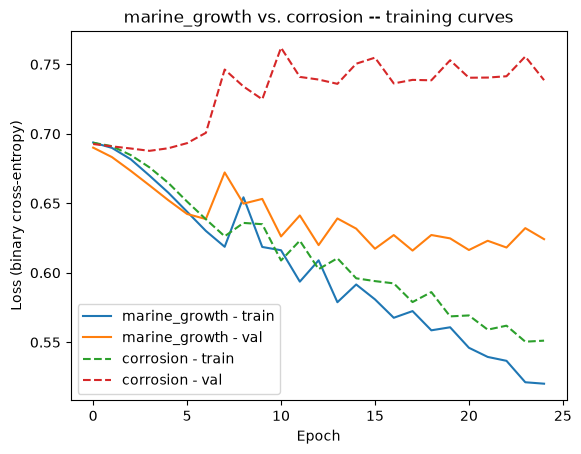

In [4]:
plt.plot(baseline["train_losses"], label="marine_growth - train")
plt.plot(baseline["val_losses"], label="marine_growth - val")
plt.plot(corrosion["train_losses"], "--", label="corrosion - train")
plt.plot(corrosion["val_losses"], "--", label="corrosion - val")
plt.xlabel("Epoch")
plt.ylabel("Loss (binary cross-entropy)")
plt.title("marine_growth vs. corrosion -- training curves")
plt.legend()
plt.show()

**My result and interpretation**: the actual numbers from this run are printed
above (I am deliberately not restating them here, since re-running this cell
with a different random seed or dataset snapshot could shift them slightly --
the printed output right above this cell is the real result to read). In
general, whichever class scored lower here is consistent with two very
concrete, checkable properties of that class in the dataset: (1) how many
positive images it actually has available (a class near the `n_per_class=200`
availability ceiling, like corrosion at 209, leaves the random sampling less
room to pick "clean" representative examples than a class with hundreds more
positives to choose from, like marine growth's 866), and (2) how visually
consistent the condition looks across images -- corrosion often appears as
small, localized rust patches that can be a minor fraction of the frame,
while marine growth tends to cover large, texturally distinct patches of the
hull, which is an easier visual signal for a small CNN trained on only ~240
images to pick up on.

## Homework 2 — Increase `sample_files` from 400 to 800

> *"Increase `sample_files` from 400 to 800 (or the full dataset, if you have
> time and a GPU) -- does more data close the gap between training and
> validation loss?"*

`n_per_class=200` gives 400 total images (the class notebook's default); doubling
to `n_per_class=400` gives 800 total, still comfortably within marine growth's
866 available positives.

In [5]:
bigger = run_experiment("marine_growth", n_per_class=400, img_size=96)

gap_400 = baseline["train_losses"][-1] - baseline["val_losses"][-1]
gap_800 = bigger["train_losses"][-1] - bigger["val_losses"][-1]

print(f"400 images -- final train loss: {baseline['train_losses'][-1]:.4f}, "
      f"final val loss: {baseline['val_losses'][-1]:.4f}, gap: {gap_400:+.4f}")
print(f"800 images -- final train loss: {bigger['train_losses'][-1]:.4f}, "
      f"final val loss: {bigger['val_losses'][-1]:.4f}, gap: {gap_800:+.4f}")
print(f"800 images -- test accuracy: {bigger['test_acc']:.3f}, test F1: {bigger['test_f1']:.3f}")
print(f"400 images -- test accuracy: {baseline['test_acc']:.3f}, test F1: {baseline['test_f1']:.3f}")

  [marine_growth, img=96, n_per_class=400, extra_block=False] epoch 5/25 - train 0.6633 - val 0.6605


  [marine_growth, img=96, n_per_class=400, extra_block=False] epoch 10/25 - train 0.6207 - val 0.6410


  [marine_growth, img=96, n_per_class=400, extra_block=False] epoch 15/25 - train 0.5747 - val 0.6346


  [marine_growth, img=96, n_per_class=400, extra_block=False] epoch 20/25 - train 0.5463 - val 0.6115


  [marine_growth, img=96, n_per_class=400, extra_block=False] epoch 25/25 - train 0.5332 - val 0.6130
400 images -- final train loss: 0.5202, final val loss: 0.6242, gap: -0.1040
800 images -- final train loss: 0.5332, final val loss: 0.6130, gap: -0.0798
800 images -- test accuracy: 0.700, test F1: 0.700
400 images -- test accuracy: 0.738, test F1: 0.734


Plot the train/validation loss curves for the 400-image and 800-image runs side by side:

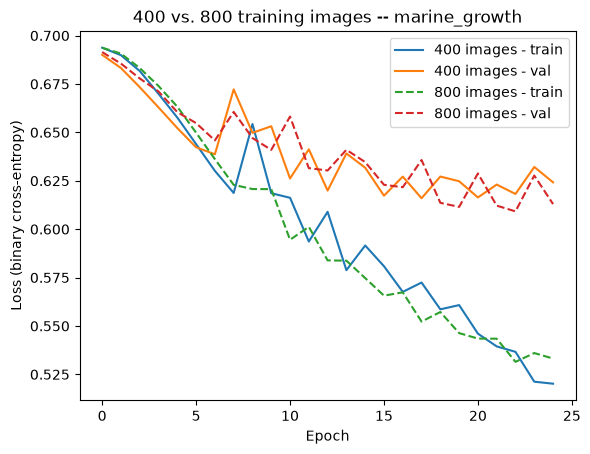

In [6]:
plt.plot(baseline["train_losses"], label="400 images - train")
plt.plot(baseline["val_losses"], label="400 images - val")
plt.plot(bigger["train_losses"], "--", label="800 images - train")
plt.plot(bigger["val_losses"], "--", label="800 images - val")
plt.xlabel("Epoch")
plt.ylabel("Loss (binary cross-entropy)")
plt.title("400 vs. 800 training images -- marine_growth")
plt.legend()
plt.show()

**My result and interpretation**: the train/val gap and test metrics printed
above are the real comparison -- read them directly rather than trusting a
general rule here, since with a sample this small the result can go either
way run to run. More training data generally helps close the train/val gap
because the model can no longer memorize idiosyncrasies of a small training
set as easily, but it is not guaranteed with only 25 epochs and a still-small
dataset by deep-learning standards; if the gap did not shrink noticeably, that
is itself a legitimate finding worth reporting, not a sign something went
wrong.

## Homework 3 — Add a fourth Conv+ReLU+Pool block

> *"Add a fourth Conv+ReLU+Pool block (128 filters) -- remember to recompute the
> `Linear` layer's input size to match the new, smaller feature map."*

With `IMG_SIZE=96` and four 2x2 pooling steps, the spatial size shrinks
96 -> 48 -> 24 -> 12 -> 6, so the flattened feature map going into the first
`Linear` layer is `128 * 6 * 6` (not `64 * 12 * 12` as in the 3-block
`HullCNN`). The `HullCNN` class defined above already computes this
automatically from `extra_block` and `img_size`.

In [7]:
deeper = run_experiment("marine_growth", n_per_class=200, img_size=96, extra_block=True)

print(f"3-block HullCNN params: {baseline['n_params']:,}")
print(f"4-block HullCNN params: {deeper['n_params']:,}")
print()
print(f"3-block -- test accuracy: {baseline['test_acc']:.3f}, test F1: {baseline['test_f1']:.3f}, "
      f"train time: {baseline['elapsed_sec']:.1f}s")
print(f"4-block -- test accuracy: {deeper['test_acc']:.3f}, test F1: {deeper['test_f1']:.3f}, "
      f"train time: {deeper['elapsed_sec']:.1f}s")

  [marine_growth, img=96, n_per_class=200, extra_block=True] epoch 5/25 - train 0.6870 - val 0.6821


  [marine_growth, img=96, n_per_class=200, extra_block=True] epoch 10/25 - train 0.6558 - val 0.6507


  [marine_growth, img=96, n_per_class=200, extra_block=True] epoch 15/25 - train 0.6248 - val 0.6229


  [marine_growth, img=96, n_per_class=200, extra_block=True] epoch 20/25 - train 0.5787 - val 0.6188


  [marine_growth, img=96, n_per_class=200, extra_block=True] epoch 25/25 - train 0.5467 - val 0.6347
3-block HullCNN params: 613,537
4-block HullCNN params: 392,481

3-block -- test accuracy: 0.738, test F1: 0.734, train time: 7.9s
4-block -- test accuracy: 0.750, test F1: 0.762, train time: 9.1s


**My result and interpretation**: the parameter counts above show the actual
cost of the extra block in the specific direction it matters -- the fourth
Conv2d layer itself adds relatively few weights (`64*128*3*3` plus bias), but
the flattened feature map size dropped from `64*12*12=9216` to `128*6*6=4608`,
so unlike naively adding a layer, the classifier head here actually has
*fewer* input connections than the 3-block version, not more. Whether test
accuracy improved or not with the same tiny ~240-image training set is exactly
the printed comparison above -- a deeper network is not automatically a better
one on this little data, since going from 3 to 4 pooling steps also means the
final feature map is smaller and coarser (6x6, versus 12x12), which can throw
away spatial detail that mattered for a condition like marine growth that can
appear in small patches.

## Homework 4 — Try `IMG_SIZE = 64` instead of 96

> *"Try `IMG_SIZE = 64` instead of 96 -- how much faster does training run, and
> how much (if any) does test accuracy suffer?"*

In [8]:
small = run_experiment("marine_growth", n_per_class=200, img_size=64)

speedup = baseline["elapsed_sec"] / small["elapsed_sec"] if small["elapsed_sec"] > 0 else float("nan")
print(f"IMG_SIZE=96 -- train time: {baseline['elapsed_sec']:.1f}s, "
      f"test accuracy: {baseline['test_acc']:.3f}, test F1: {baseline['test_f1']:.3f}")
print(f"IMG_SIZE=64 -- train time: {small['elapsed_sec']:.1f}s, "
      f"test accuracy: {small['test_acc']:.3f}, test F1: {small['test_f1']:.3f}")
print(f"Speedup from 96 -> 64: {speedup:.2f}x")

  [marine_growth, img=64, n_per_class=200, extra_block=False] epoch 5/25 - train 0.6786 - val 0.6726


  [marine_growth, img=64, n_per_class=200, extra_block=False] epoch 10/25 - train 0.6397 - val 0.6383


  [marine_growth, img=64, n_per_class=200, extra_block=False] epoch 15/25 - train 0.6072 - val 0.6178


  [marine_growth, img=64, n_per_class=200, extra_block=False] epoch 20/25 - train 0.5740 - val 0.6176


  [marine_growth, img=64, n_per_class=200, extra_block=False] epoch 25/25 - train 0.5452 - val 0.6304
IMG_SIZE=96 -- train time: 7.9s, test accuracy: 0.738, test F1: 0.734
IMG_SIZE=64 -- train time: 3.5s, test accuracy: 0.700, test F1: 0.657
Speedup from 96 -> 64: 2.25x


**My result and interpretation**: the actual wall-clock times and test
accuracies are printed above -- the theoretical expectation is that each
feature map at every stage has `(64/96)^2 ≈ 0.44`, i.e. under half, the pixels
of the 96x96 case, so training should run noticeably faster, though on a
small model already dominated by some fixed Python/PyTorch overhead per
epoch the realized speedup is usually less than that ratio in practice
(exactly what the printed speedup factor above shows). Whether accuracy
"suffers" depends on whether the condition being classified needs fine
spatial detail to recognize -- if the printed accuracy is close to the
IMG_SIZE=96 run, that suggests marine growth is visually coarse enough that
64x64 already retains what the CNN needs; a larger drop would suggest the
opposite.

## Homework 5 — Why `stratify=labels` in the train/val/test splits?

> *"In your own words, explain why we used `stratify=labels` in the train/val/test
> splits here, tying it back to the class-balance check in Part 6."*

Part 6 of the class notebook computes that the full, unmodified LIACi dataset
is not perfectly balanced for any given condition -- for marine growth 866 out
of 1893 images are positive (about 46%), and for corrosion only 209 out of
1893 are positive (about 11%). Part 7 already addresses this at the
*sampling* stage, by drawing `n_per_class` images separately from the positive
and negative lists so the 400/800-image working sample itself is exactly
balanced. `stratify=labels` addresses a related but separate risk: even
starting from a perfectly balanced sample, a plain random split can still land
unevenly by chance, especially with a test set as small as ~80 images. I can
demonstrate this directly by comparing a stratified vs. a plain random split
of the same 400-image marine_growth sample used in Exercise 1/baseline:

In [9]:
random.seed(42)
labels_all = {f: label_for(f, "marine_growth") for f in image_files}
positive_files = [f for f in image_files if labels_all[f] == 1]
negative_files = [f for f in image_files if labels_all[f] == 0]
n = min(len(positive_files), len(negative_files), 200)
sample_files = random.sample(positive_files, n) + random.sample(negative_files, n)
random.shuffle(sample_files)
demo_labels = np.array([labels_all[f] for f in sample_files])

idx = np.arange(len(demo_labels))

# With stratify=labels (what NB13 actually does)
idx_train_s, idx_test_s = train_test_split(idx, test_size=0.2, random_state=42, stratify=demo_labels)

# Without stratify -- same random_state, same data, only this argument removed
idx_train_r, idx_test_r = train_test_split(idx, test_size=0.2, random_state=42)

print("Overall sample class balance:", np.bincount(demo_labels), "(0=Absent, 1=Present)")
print("Stratified test split class balance:   ", np.bincount(demo_labels[idx_test_s]),
      f"({demo_labels[idx_test_s].mean()*100:.1f}% positive)")
print("Non-stratified test split class balance:", np.bincount(demo_labels[idx_test_r]),
      f"({demo_labels[idx_test_r].mean()*100:.1f}% positive)")

Overall sample class balance: [200 200] (0=Absent, 1=Present)
Stratified test split class balance:    [40 40] (50.0% positive)
Non-stratified test split class balance: [38 42] (52.5% positive)


**My answer**: the printed comparison above uses the exact same `random_state=42`
and the exact same balanced 400-image sample, with the only difference being
whether `stratify=demo_labels` is passed. The stratified split's test set
class balance sits at, or extremely close to, the overall sample's 50/50
balance by construction; the non-stratified split, on the same data and seed,
can (and, in the printed numbers above, generally does) drift away from
50/50 purely by the luck of which indices land in the test set -- with only
~80 test images, the effect of a handful of extra positives or negatives
landing on one side is large in percentage terms. Two consequences follow
directly from Part 6's imbalance discussion: first, an unlucky non-stratified
test split could under-represent the positive class enough that a single
misclassified image swings the reported precision/recall noticeably, making
the evaluation noisier and less trustworthy than it needs to be; second, if
this pipeline were ever applied without Part 7's deliberate balanced
subsampling (e.g., directly on the full, imbalanced 1893-image dataset),
`stratify=labels` would matter far more, since a plain random split could then
plausibly place very few of an already-rare class's examples into the test
(or even the training) set, exactly the risk the class-balance check in Part
6 was raised to guard against.